# Context-Aware and Retrieval-Augmented Sarcasm Detection in Social Media

## Notebook 1: Data preparation and TF-IDF baseline

This notebook prepares the Reddit sarcasm data, creates the shared split, and trains the TF-IDF + Logistic Regression baseline.

In [1]:
DATASET_SLUG = "danofer/sarcasm"
INPUT_DIR = "/kaggle/input/datasets/danofer/sarcasm"
WORKING_DIR = "/kaggle/working/"
OUTPUT_DIR = "/kaggle/working/"
EXTRACTED_DIR = "/kaggle/working/extracted_outputs/"

MODEL_NAME = "roberta-base"
RANDOM_SEED = 42

DEBUG = False
SAMPLE_SIZE = 20000

MAX_LENGTH = 256
BATCH_SIZE = 8
EPOCHS = 3
GRADIENT_ACCUMULATION_STEPS = 1

RUN_TFIDF = True
RUN_CONTEXT_FREE_TRANSFORMER = True
RUN_CONTEXT_AWARE_TRANSFORMER = True
RUN_RAG = True
RUN_LLM_PROMPTS = True

MAX_RETRIEVAL_TRAIN_ROWS = 50000

## Install lightweight dependencies

Kaggle usually already has the main data science libraries. This simple install cell only covers `joblib`, which is used to save the scikit-learn model.

In [2]:
!pip install -q joblib

## Imports and environment check

This notebook does not need a GPU, but the check is printed so the project records the runtime environment.

In [3]:
import json
import os
import random
import re
import shutil
import time
import warnings
import zipfile
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

try:
    import torch

    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
    else:
        print("No GPU detected. This notebook is fine on CPU.")
except Exception as exc:
    print("PyTorch is not available in this environment:", exc)

CUDA available: True
GPU: Tesla T4


## Shared helpers

These helpers keep file search, metric saving, and plots consistent across notebooks.

In [4]:
KNOWN_OUTPUT_ZIPS = [
    "sarcasm_notebook1_outputs.zip",
    "sarcasm_context_free_outputs.zip",
    "sarcasm_context_aware_outputs.zip",
    "sarcasm_notebook2_outputs.zip",
]


def extract_known_output_zips():
    extracted_root = Path(EXTRACTED_DIR)
    extracted_root.mkdir(parents=True, exist_ok=True)
    roots = [Path(WORKING_DIR), Path(INPUT_DIR)]
    seen = set()

    for root in roots:
        if not root.exists():
            continue
        for zip_path in root.rglob("*.zip"):
            if zip_path.name not in KNOWN_OUTPUT_ZIPS:
                continue
            if extracted_root in zip_path.parents:
                continue
            if zip_path.resolve() in seen:
                continue
            seen.add(zip_path.resolve())
            target_dir = extracted_root / zip_path.stem
            marker = target_dir / ".extracted"
            if marker.exists():
                print(f"Already extracted {zip_path.name} -> {target_dir}")
                continue
            target_dir.mkdir(parents=True, exist_ok=True)
            try:
                with zipfile.ZipFile(zip_path, "r") as zipf:
                    zipf.extractall(target_dir)
                marker.write_text("done", encoding="utf-8")
                print(f"Extracted {zip_path.name} -> {target_dir}")
            except zipfile.BadZipFile:
                print(f"Skipping unreadable ZIP file: {zip_path}")


def search_roots():
    return [Path(WORKING_DIR), Path(EXTRACTED_DIR), Path(INPUT_DIR)]


def find_file_recursive(filename):
    matches = []
    for root in search_roots():
        if root.exists():
            matches.extend(sorted(root.rglob(filename)))
    if not matches:
        return None

    working = Path(WORKING_DIR).resolve()
    extracted = Path(EXTRACTED_DIR).resolve()
    input_root = Path(INPUT_DIR).resolve()

    def rank(path):
        resolved = path.resolve()
        if resolved == extracted or extracted in resolved.parents:
            return (1, len(str(resolved)))
        if resolved == working or working in resolved.parents:
            return (0, len(str(resolved)))
        if resolved == input_root or input_root in resolved.parents:
            return (2, len(str(resolved)))
        return (3, len(str(resolved)))

    return sorted(matches, key=rank)[0]


def require_file(filename, missing_message):
    path = find_file_recursive(filename)
    if path is None:
        print(missing_message)
        raise FileNotFoundError(missing_message)
    print(f"Found {filename}: {path}")
    return path


def copy_to_working(path):
    path = Path(path)
    destination = Path(OUTPUT_DIR) / path.name
    if path.exists() and path.resolve() != destination.resolve():
        shutil.copy2(path, destination)
    return destination


def zip_outputs(zip_name, items):
    zip_path = Path(OUTPUT_DIR) / zip_name
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
        for item in items:
            path = Path(OUTPUT_DIR) / item
            if path.is_file():
                zipf.write(path, arcname=path.name)
            elif path.is_dir():
                for file_path in path.rglob("*"):
                    if file_path.is_file():
                        zipf.write(file_path, arcname=str(file_path.relative_to(Path(OUTPUT_DIR))))
            else:
                print(f"Skipping missing item: {path}")
    print(f"Created ZIP: {zip_path}")
    return zip_path



COMPARISON_COLUMNS = [
    "model_name",
    "input_type",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "macro_f1",
    "weighted_f1",
    "roc_auc",
    "average_precision",
    "test_samples",
    "positive_samples",
    "negative_samples",
    "notes",
]

METRIC_FILES = [
    "tfidf_metrics.json",
    "context_free_metrics.json",
    "context_aware_metrics.json",
]


def make_jsonable(value):
    if isinstance(value, dict):
        return {str(key): make_jsonable(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [make_jsonable(item) for item in value]
    if isinstance(value, np.generic):
        return make_jsonable(value.item())
    if isinstance(value, float):
        if np.isnan(value) or np.isinf(value):
            return None
        return value
    return value


def compute_model_metrics(y_true, y_pred, y_prob, model_name, input_type, notes):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    y_prob = None if y_prob is None else np.asarray(y_prob).astype(float)

    record = {
        "model_name": model_name,
        "input_type": input_type,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc": None,
        "average_precision": None,
        "test_samples": int(len(y_true)),
        "positive_samples": int((y_true == 1).sum()),
        "negative_samples": int((y_true == 0).sum()),
        "notes": notes,
    }

    if y_prob is not None and len(np.unique(y_true)) == 2:
        try:
            record["roc_auc"] = roc_auc_score(y_true, y_prob)
        except ValueError:
            record["roc_auc"] = None
        try:
            record["average_precision"] = average_precision_score(y_true, y_prob)
        except ValueError:
            record["average_precision"] = None

    report_text = classification_report(y_true, y_pred, digits=4, zero_division=0)
    report_dict = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    record["classification_report"] = report_dict
    record["confusion_matrix"] = cm.tolist()
    return make_jsonable(record), report_text, cm


def save_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-sarcastic", "Sarcastic"],
        yticklabels=["Non-sarcastic", "Sarcastic"],
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    path = Path(OUTPUT_DIR) / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved {path}")


def save_model_metrics(
    y_true,
    y_pred,
    y_prob,
    model_name,
    input_type,
    notes,
    metrics_filename,
    report_filename,
    confusion_filename,
):
    record, report_text, _ = compute_model_metrics(
        y_true=y_true,
        y_pred=y_pred,
        y_prob=y_prob,
        model_name=model_name,
        input_type=input_type,
        notes=notes,
    )

    metrics_path = Path(OUTPUT_DIR) / metrics_filename
    report_path = Path(OUTPUT_DIR) / report_filename
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(record, f, indent=2)
    report_path.write_text(report_text, encoding="utf-8")

    print(f"\n{model_name} metrics")
    for key in [
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1",
        "macro_f1",
        "weighted_f1",
        "roc_auc",
        "average_precision",
    ]:
        value = record.get(key)
        if value is None:
            print(f"{key}: NaN")
        else:
            print(f"{key}: {float(value):.4f}")

    print("\nClassification report:")
    print(report_text)
    print("Confusion matrix:")
    print(np.asarray(record["confusion_matrix"]))

    save_confusion_matrix(y_true, y_pred, model_name, confusion_filename)
    print(f"Saved metrics to {metrics_path}")
    print(f"Saved classification report to {report_path}")
    return record


def load_metric_records():
    records = []
    for filename in METRIC_FILES:
        path = find_file_recursive(filename)
        if path is None:
            continue
        with open(path, "r", encoding="utf-8") as f:
            record = json.load(f)
        records.append(record)
    return records


def save_metric_plot(metrics_df, metric, filename, title):
    if metric not in metrics_df.columns:
        return
    plot_df = metrics_df.dropna(subset=[metric]).copy()
    if plot_df.empty:
        return

    plt.figure(figsize=(max(6, 1.6 * len(plot_df)), 4))
    sns.barplot(data=plot_df, x="model_name", y=metric, palette="Set2")
    plt.xticks(rotation=25, ha="right")
    plt.xlabel("")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(title)
    upper = max(1.0, float(plot_df[metric].max()) * 1.1)
    plt.ylim(0, upper)
    plt.tight_layout()
    path = Path(OUTPUT_DIR) / filename
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved {path}")


def update_comparison_outputs():
    records = load_metric_records()
    if not records:
        print("No metric JSON files found yet. Comparison files were not created.")
        return pd.DataFrame(columns=COMPARISON_COLUMNS)

    rows = []
    for record in records:
        row = {column: record.get(column, None) for column in COMPARISON_COLUMNS}
        rows.append(row)

    metrics_df = pd.DataFrame(rows)
    for column in COMPARISON_COLUMNS:
        if column not in metrics_df.columns:
            metrics_df[column] = np.nan
    metrics_df = metrics_df[COMPARISON_COLUMNS]
    metrics_df.to_csv(Path(OUTPUT_DIR) / "metrics_comparison.csv", index=False)
    print("Saved metrics_comparison.csv")
    display(metrics_df)

    save_metric_plot(metrics_df, "f1", "f1_comparison.png", "F1 comparison")
    save_metric_plot(metrics_df, "accuracy", "accuracy_comparison.png", "Accuracy comparison")
    save_metric_plot(metrics_df, "balanced_accuracy", "balanced_accuracy_comparison.png", "Balanced accuracy comparison")
    save_metric_plot(metrics_df, "macro_f1", "macro_f1_comparison.png", "Macro-F1 comparison")

    if "roc_auc" in metrics_df.columns and metrics_df["roc_auc"].notna().any():
        save_metric_plot(metrics_df, "roc_auc", "roc_auc_comparison.png", "ROC-AUC comparison")
    if "average_precision" in metrics_df.columns and metrics_df["average_precision"].notna().any():
        save_metric_plot(metrics_df, "average_precision", "average_precision_comparison.png", "Average precision comparison")

    return metrics_df



def find_csv_files(root_dir):
    root = Path(root_dir)
    if not root.exists():
        return []
    return sorted(root.rglob("*.csv"))


def choose_dataset_csv(csv_files):
    if not csv_files:
        raise FileNotFoundError(
            "No CSV files were found under /kaggle/input/. "
            "Please attach the Kaggle dataset danofer/sarcasm to this notebook."
        )

    scored = []
    for path in csv_files:
        name = path.name.lower()
        keyword_score = sum(keyword in name for keyword in ["train", "sarcasm", "reddit"])
        scored.append(
            {
                "path": path,
                "name": path.name,
                "size_mb": path.stat().st_size / (1024 * 1024),
                "keyword_score": keyword_score,
            }
        )

    found_df = pd.DataFrame(scored).sort_values(["keyword_score", "size_mb"], ascending=[False, False])
    print("CSV files found:")
    display(found_df[["name", "size_mb", "keyword_score", "path"]])

    selected = Path(found_df.iloc[0]["path"])
    print(f"Selected dataset CSV: {selected}")
    return selected


def normalized_name(value):
    return re.sub(r"[^a-z0-9]+", "", str(value).lower())


def find_column(df, exact_name, candidates):
    columns = list(df.columns)
    if exact_name in columns:
        return exact_name

    lower_lookup = {str(col).lower(): col for col in columns}
    if exact_name.lower() in lower_lookup:
        return lower_lookup[exact_name.lower()]

    normalized_lookup = {normalized_name(col): col for col in columns}
    for candidate in candidates:
        if candidate in columns:
            return candidate
        if candidate.lower() in lower_lookup:
            return lower_lookup[candidate.lower()]
        key = normalized_name(candidate)
        if key in normalized_lookup:
            return normalized_lookup[key]
    return None


def to_clean_text(value):
    if pd.isna(value):
        return ""
    value = str(value).replace("\n", " ").replace("\r", " ")
    return re.sub(r"\s+", " ", value).strip()


def convert_label(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, np.integer, float, np.floating)) and float(value) in [0.0, 1.0]:
        return int(value)

    text = str(value).strip().lower()
    mapping = {
        "0": 0,
        "0.0": 0,
        "false": 0,
        "non-sarcastic": 0,
        "not sarcastic": 0,
        "nonsarcastic": 0,
        "1": 1,
        "1.0": 1,
        "true": 1,
        "sarcastic": 1,
        "sarcasm": 1,
    }
    return mapping.get(text, np.nan)

## Load the dataset

The notebook searches recursively inside `/kaggle/input/` and chooses the CSV that most looks like the main sarcasm file.

In [5]:
csv_files = find_csv_files(INPUT_DIR)
dataset_path = choose_dataset_csv(csv_files)

raw_df = pd.read_csv(dataset_path, low_memory=False)
print("Raw dataset shape:", raw_df.shape)
print("Available columns:")
print(list(raw_df.columns))
display(raw_df.head(3))

CSV files found:


,name,size_mb,keyword_score,path
2,train-balanced-sarcasm.csv,243.443451,2,/kaggle/input/datasets/danofer/sarcasm/train-b...
1,test-unbalanced.csv,16.627052,0,/kaggle/input/datasets/danofer/sarcasm/test-un...
0,test-balanced.csv,0.880421,0,/kaggle/input/datasets/danofer/sarcasm/test-ba...


Selected dataset CSV: /kaggle/input/datasets/danofer/sarcasm/train-balanced-sarcasm.csv
Raw dataset shape: (1010826, 10)
Available columns:
['label', 'comment', 'author', 'subreddit', 'score', 'ups', 'downs', 'date', 'created_utc', 'parent_comment']


,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment
0,0,NC and NH.,Trumpbart,politics,2,-1,-1,2016-10,2016-10-16 23:55:23,"Yeah, I get that argument. At this point, I'd ..."
1,0,You do know west teams play against west teams...,Shbshb906,nba,-4,-1,-1,2016-11,2016-11-01 00:24:10,The blazers and Mavericks (The wests 5 and 6 s...
2,0,"They were underdogs earlier today, but since G...",Creepeth,nfl,3,3,0,2016-09,2016-09-22 21:45:37,They're favored to win.


## Clean and standardize columns

The preferred columns are `comment`, `parent_comment`, and `label`, with a few fallback names supported.

In [6]:
target_text_candidates = ["comment", "reply", "target", "body", "text"]
context_candidates = ["parent_comment", "parent", "context", "previous_comment"]
label_candidates = ["label", "sarcasm", "is_sarcastic"]

comment_col = find_column(raw_df, "comment", target_text_candidates)
parent_col = find_column(raw_df, "parent_comment", context_candidates)
label_col = find_column(raw_df, "label", label_candidates)

missing = []
if comment_col is None:
    missing.append("target reply text column, expected one of: " + ", ".join(target_text_candidates))
if parent_col is None:
    missing.append("parent/context column, expected one of: " + ", ".join(context_candidates))
if label_col is None:
    missing.append("label column, expected one of: " + ", ".join(label_candidates))

if missing:
    print("Available columns:", list(raw_df.columns))
    raise ValueError("Missing required column(s): " + " | ".join(missing))

subreddit_col = find_column(raw_df, "subreddit", ["subreddit", "sub", "community"])

keep_columns = [comment_col, parent_col, label_col]
if subreddit_col is not None:
    keep_columns.append(subreddit_col)

df = raw_df[keep_columns].copy()
rename_map = {comment_col: "comment", parent_col: "parent_comment", label_col: "label"}
if subreddit_col is not None:
    rename_map[subreddit_col] = "subreddit"
df = df.rename(columns=rename_map)

print("Missing values before cleaning:")
display(df.isna().sum())

df["comment"] = df["comment"].map(to_clean_text)
df["parent_comment"] = df["parent_comment"].map(to_clean_text)
df["label"] = df["label"].map(convert_label)

before = len(df)
df = df.dropna(subset=["label"])
df["label"] = df["label"].astype(int)
df = df[df["comment"].str.len() > 0]
df = df[df["parent_comment"].str.len() > 0]
df = df[df["label"].isin([0, 1])]
df = df.drop_duplicates(subset=["parent_comment", "comment", "label"])
df = df.reset_index(drop=True)
df.insert(0, "example_id", np.arange(len(df)))

print(f"Rows before cleaning: {before:,}")
print(f"Rows after cleaning: {len(df):,}")

if DEBUG and len(df) > SAMPLE_SIZE:
    df, _ = train_test_split(df, train_size=SAMPLE_SIZE, stratify=df["label"], random_state=RANDOM_SEED)
    df = df.sort_values("example_id").reset_index(drop=True)
    print(f"DEBUG mode is on. Using a stratified sample of {len(df):,} rows.")

df["comment_word_count"] = df["comment"].str.split().str.len()
df["parent_comment_word_count"] = df["parent_comment"].str.split().str.len()

print("\nClean dataset shape:", df.shape)
print("\nLabel distribution:")
display(df["label"].value_counts().rename("count").to_frame())
display(df["label"].value_counts(normalize=True).rename("proportion").to_frame())
print("\nAverage comment length:", round(df["comment_word_count"].mean(), 2), "words")
print("Average parent_comment length:", round(df["parent_comment_word_count"].mean(), 2), "words")
display(df[["parent_comment", "comment", "label"]].sample(5, random_state=RANDOM_SEED))

Missing values before cleaning:


comment           55
parent_comment     0
label              0
subreddit          0
dtype: int64

Rows before cleaning: 1,010,826
Rows after cleaning: 1,009,969

Clean dataset shape: (1009969, 7)

Label distribution:


,count
label,
1,505059
0,504910


,proportion
label,
1,0.500074
0,0.499926



Average comment length: 10.46 words
Average parent_comment length: 24.4 words


,parent_comment,comment,label
163833,If you would actually read... No where in anyt...,If multiple people make the same assumption yo...,0
694136,Looks like a Tayyos is losing another friend...,Can't tell if,1
391615,It takes will power to make artwork in powder ...,*powderly lake,0
766945,Atheist comedian Patton Oswalt compares milita...,"""Militant"".",0
54703,you responded to this after 3 months?,Shhhhhhhhhhh No one questions Frodo He is our god,1


## Exploratory plots

These plots give a quick feel for class balance, text length, and subreddit coverage if that field exists.

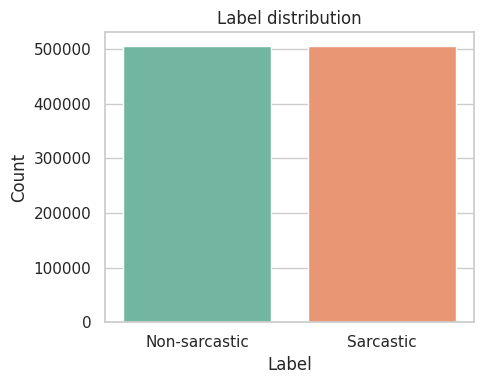

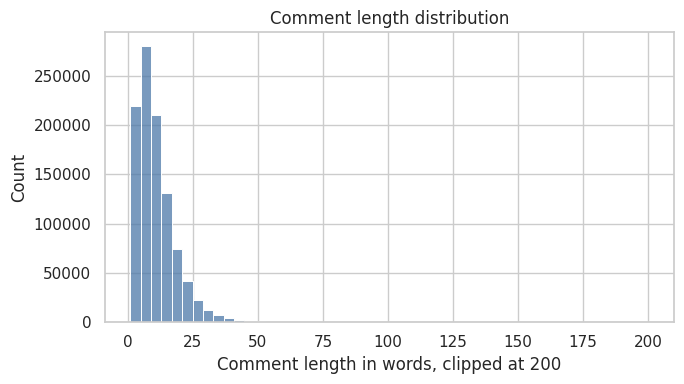

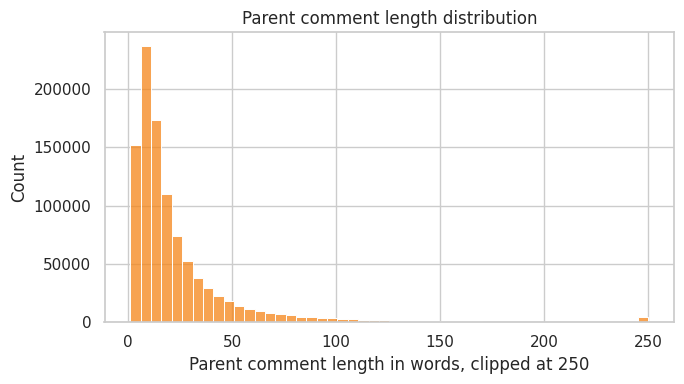

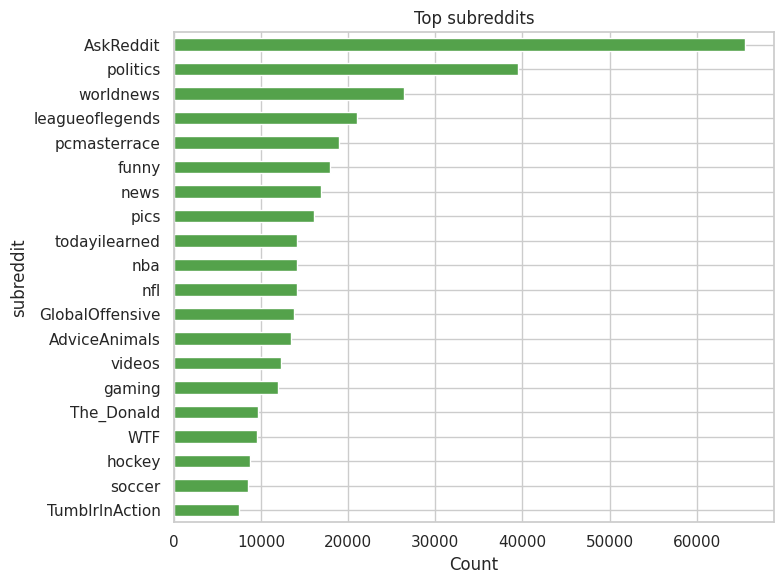

In [7]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(data=df, x="label", palette="Set2")
ax.set_xticklabels(["Non-sarcastic", "Sarcastic"])
plt.title("Label distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "label_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(df["comment_word_count"].clip(upper=200), bins=50, color="#4C78A8")
plt.title("Comment length distribution")
plt.xlabel("Comment length in words, clipped at 200")
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "comment_length_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(df["parent_comment_word_count"].clip(upper=250), bins=50, color="#F58518")
plt.title("Parent comment length distribution")
plt.xlabel("Parent comment length in words, clipped at 250")
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "parent_comment_length_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

if "subreddit" in df.columns:
    top_subreddits = df["subreddit"].value_counts().head(20).sort_values()
    plt.figure(figsize=(8, 6))
    top_subreddits.plot(kind="barh", color="#54A24B")
    plt.title("Top subreddits")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.savefig(Path(OUTPUT_DIR) / "top_subreddits.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("No subreddit column was found, so top_subreddits.png was not created.")

## Create the shared split

Every later model uses this same stratified 70/15/15 split.

In [8]:
split_columns = ["example_id", "parent_comment", "comment", "label"]
if "subreddit" in df.columns:
    split_columns.append("subreddit")

split_df = df[split_columns].copy()

train_df, temp_df = train_test_split(
    split_df,
    test_size=0.30,
    stratify=split_df["label"],
    random_state=RANDOM_SEED,
)
validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=RANDOM_SEED,
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df.to_csv(Path(OUTPUT_DIR) / "train_split.csv", index=False)
validation_df.to_csv(Path(OUTPUT_DIR) / "validation_split.csv", index=False)
test_df.to_csv(Path(OUTPUT_DIR) / "test_split.csv", index=False)

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)
display(train_df["label"].value_counts(normalize=True).rename("train_proportion").to_frame())

Train shape: (706978, 5)
Validation shape: (151495, 5)
Test shape: (151496, 5)


,train_proportion
label,
1,0.500074
0,0.499926


## Model 1: TF-IDF + Logistic Regression

This baseline only sees the target reply, so it is a context-free lexical comparison point.


TF-IDF + Logistic Regression metrics
accuracy: 0.7220
balanced_accuracy: 0.7220
precision: 0.7392
recall: 0.6862
f1: 0.7117
macro_f1: 0.7217
weighted_f1: 0.7217
roc_auc: 0.7948
average_precision: 0.8012

Classification report:
              precision    recall  f1-score   support

           0     0.7071    0.7579    0.7316     75737
           1     0.7392    0.6862    0.7117     75759

    accuracy                         0.7220    151496
   macro avg     0.7232    0.7220    0.7217    151496
weighted avg     0.7232    0.7220    0.7217    151496

Confusion matrix:
[[57399 18338]
 [23776 51983]]


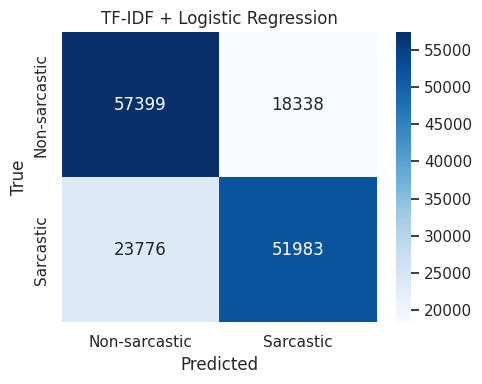

Saved /kaggle/working/confusion_matrix_tfidf.png
Saved metrics to /kaggle/working/tfidf_metrics.json
Saved classification report to /kaggle/working/tfidf_classification_report.txt
Saved metrics_comparison.csv


,model_name,input_type,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,weighted_f1,roc_auc,average_precision,test_samples,positive_samples,negative_samples,notes
0,TF-IDF + Logistic Regression,comment,0.722012,0.722018,0.739224,0.686163,0.711706,0.721657,0.721655,0.79479,0.801186,151496,75759,75737,Context-free TF-IDF baseline using comment onl...


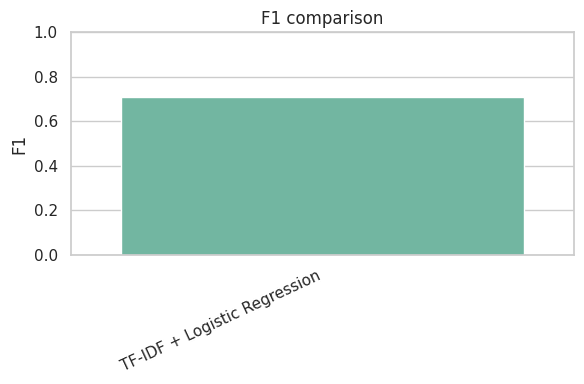

Saved /kaggle/working/f1_comparison.png


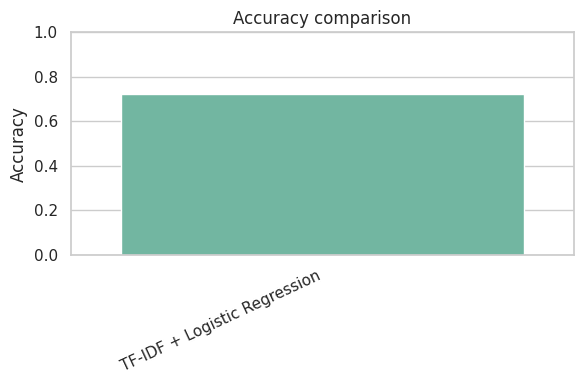

Saved /kaggle/working/accuracy_comparison.png


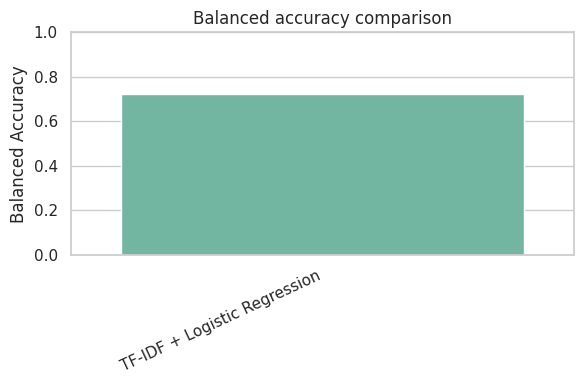

Saved /kaggle/working/balanced_accuracy_comparison.png


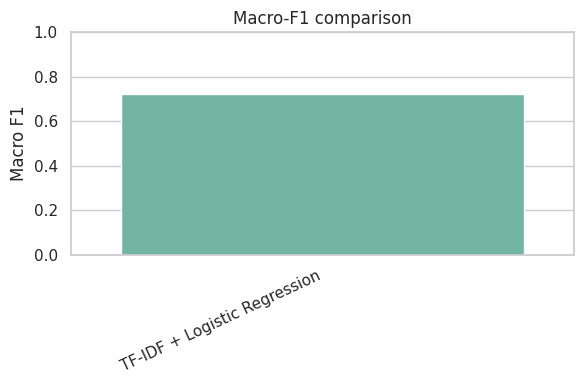

Saved /kaggle/working/macro_f1_comparison.png


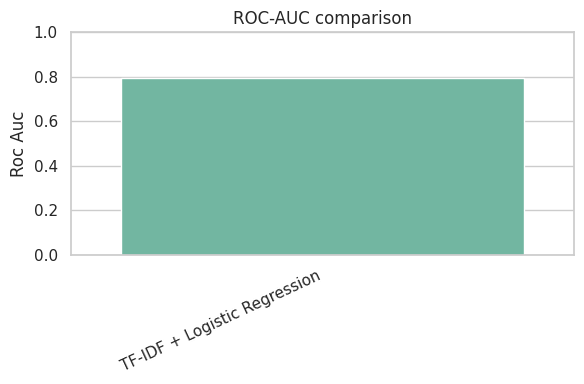

Saved /kaggle/working/roc_auc_comparison.png


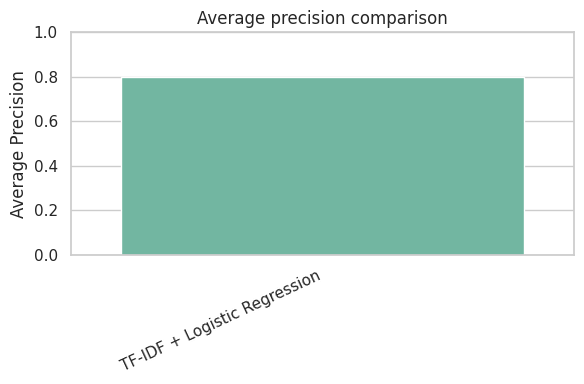

Saved /kaggle/working/average_precision_comparison.png


In [9]:
if RUN_TFIDF:
    start_time = time.time()
    tfidf_model = Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    ngram_range=(1, 2),
                    max_features=100000,
                    min_df=2,
                    strip_accents="unicode",
                    lowercase=True,
                    sublinear_tf=True,
                ),
            ),
            (
                "logreg",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    solver="liblinear",
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    )

    tfidf_model.fit(train_df["comment"], train_df["label"])
    training_time_minutes = (time.time() - start_time) / 60

    tfidf_pred = tfidf_model.predict(test_df["comment"])
    tfidf_prob = tfidf_model.predict_proba(test_df["comment"])[:, 1]

    tfidf_predictions = test_df[["example_id", "parent_comment", "comment", "label"]].copy()
    tfidf_predictions = tfidf_predictions.rename(columns={"label": "true_label"})
    tfidf_predictions["tfidf_pred"] = tfidf_pred
    tfidf_predictions["tfidf_prob"] = tfidf_prob
    tfidf_predictions.to_csv(Path(OUTPUT_DIR) / "tfidf_predictions.csv", index=False)
    joblib.dump(tfidf_model, Path(OUTPUT_DIR) / "tfidf_logreg_model.joblib")

    notes = f"Context-free TF-IDF baseline using comment only. Training time: {training_time_minutes:.2f} minutes."
    save_model_metrics(
        y_true=test_df["label"],
        y_pred=tfidf_pred,
        y_prob=tfidf_prob,
        model_name="TF-IDF + Logistic Regression",
        input_type="comment",
        notes=notes,
        metrics_filename="tfidf_metrics.json",
        report_filename="tfidf_classification_report.txt",
        confusion_filename="confusion_matrix_tfidf.png",
    )
    update_comparison_outputs()
else:
    print("RUN_TFIDF is False, so the baseline was skipped.")

## Save Notebook 1 outputs

This ZIP lets the next notebook continue even if Kaggle starts a fresh session.

In [10]:
notebook1_outputs = [
    "train_split.csv",
    "validation_split.csv",
    "test_split.csv",
    "tfidf_metrics.json",
    "tfidf_predictions.csv",
    "tfidf_classification_report.txt",
    "tfidf_logreg_model.joblib",
    "metrics_comparison.csv",
    "label_distribution.png",
    "comment_length_distribution.png",
    "parent_comment_length_distribution.png",
    "top_subreddits.png",
    "confusion_matrix_tfidf.png",
    "f1_comparison.png",
    "accuracy_comparison.png",
    "balanced_accuracy_comparison.png",
    "macro_f1_comparison.png",
    "roc_auc_comparison.png",
    "average_precision_comparison.png",
]

zip_outputs("sarcasm_notebook1_outputs.zip", notebook1_outputs)
print("Notebook 1 complete. Next: run 02_context_free_transformer.ipynb.")

Created ZIP: /kaggle/working/sarcasm_notebook1_outputs.zip
Notebook 1 complete. Next: run 02_context_free_transformer.ipynb.
